In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/스트레스 테스트 9차/train.csv')

In [ ]:
train.head(3)

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

In [ ]:
train.describe()

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,1968.000000,3000.000000
mean,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,8.716972,0.482130
std,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,1.628944,0.288252
min,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,4.000000,0.000000
25%,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,8.000000,0.230000
50%,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,9.000000,0.480000
75%,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,10.000000,0.730000
max,89.00000,195.280000,120.880000,313.350000,191.000000,124.000000,185.740000,2.000000,16.000000,1.000000


In [ ]:
potential_zeros = []
zero_counts = (train[potential_zeros] == 0).sum()
print(zero_counts)

Series([], dtype: float64)


In [ ]:
missing_values = train.isnull().sum()
display(missing_values)

,0
ID,0
gender,0
age,0
height,0
weight,0
cholesterol,0
systolic_blood_pressure,0
diastolic_blood_pressure,0
glucose,0
bone_density,0


In [ ]:
import matplotlib.pyplot as plt

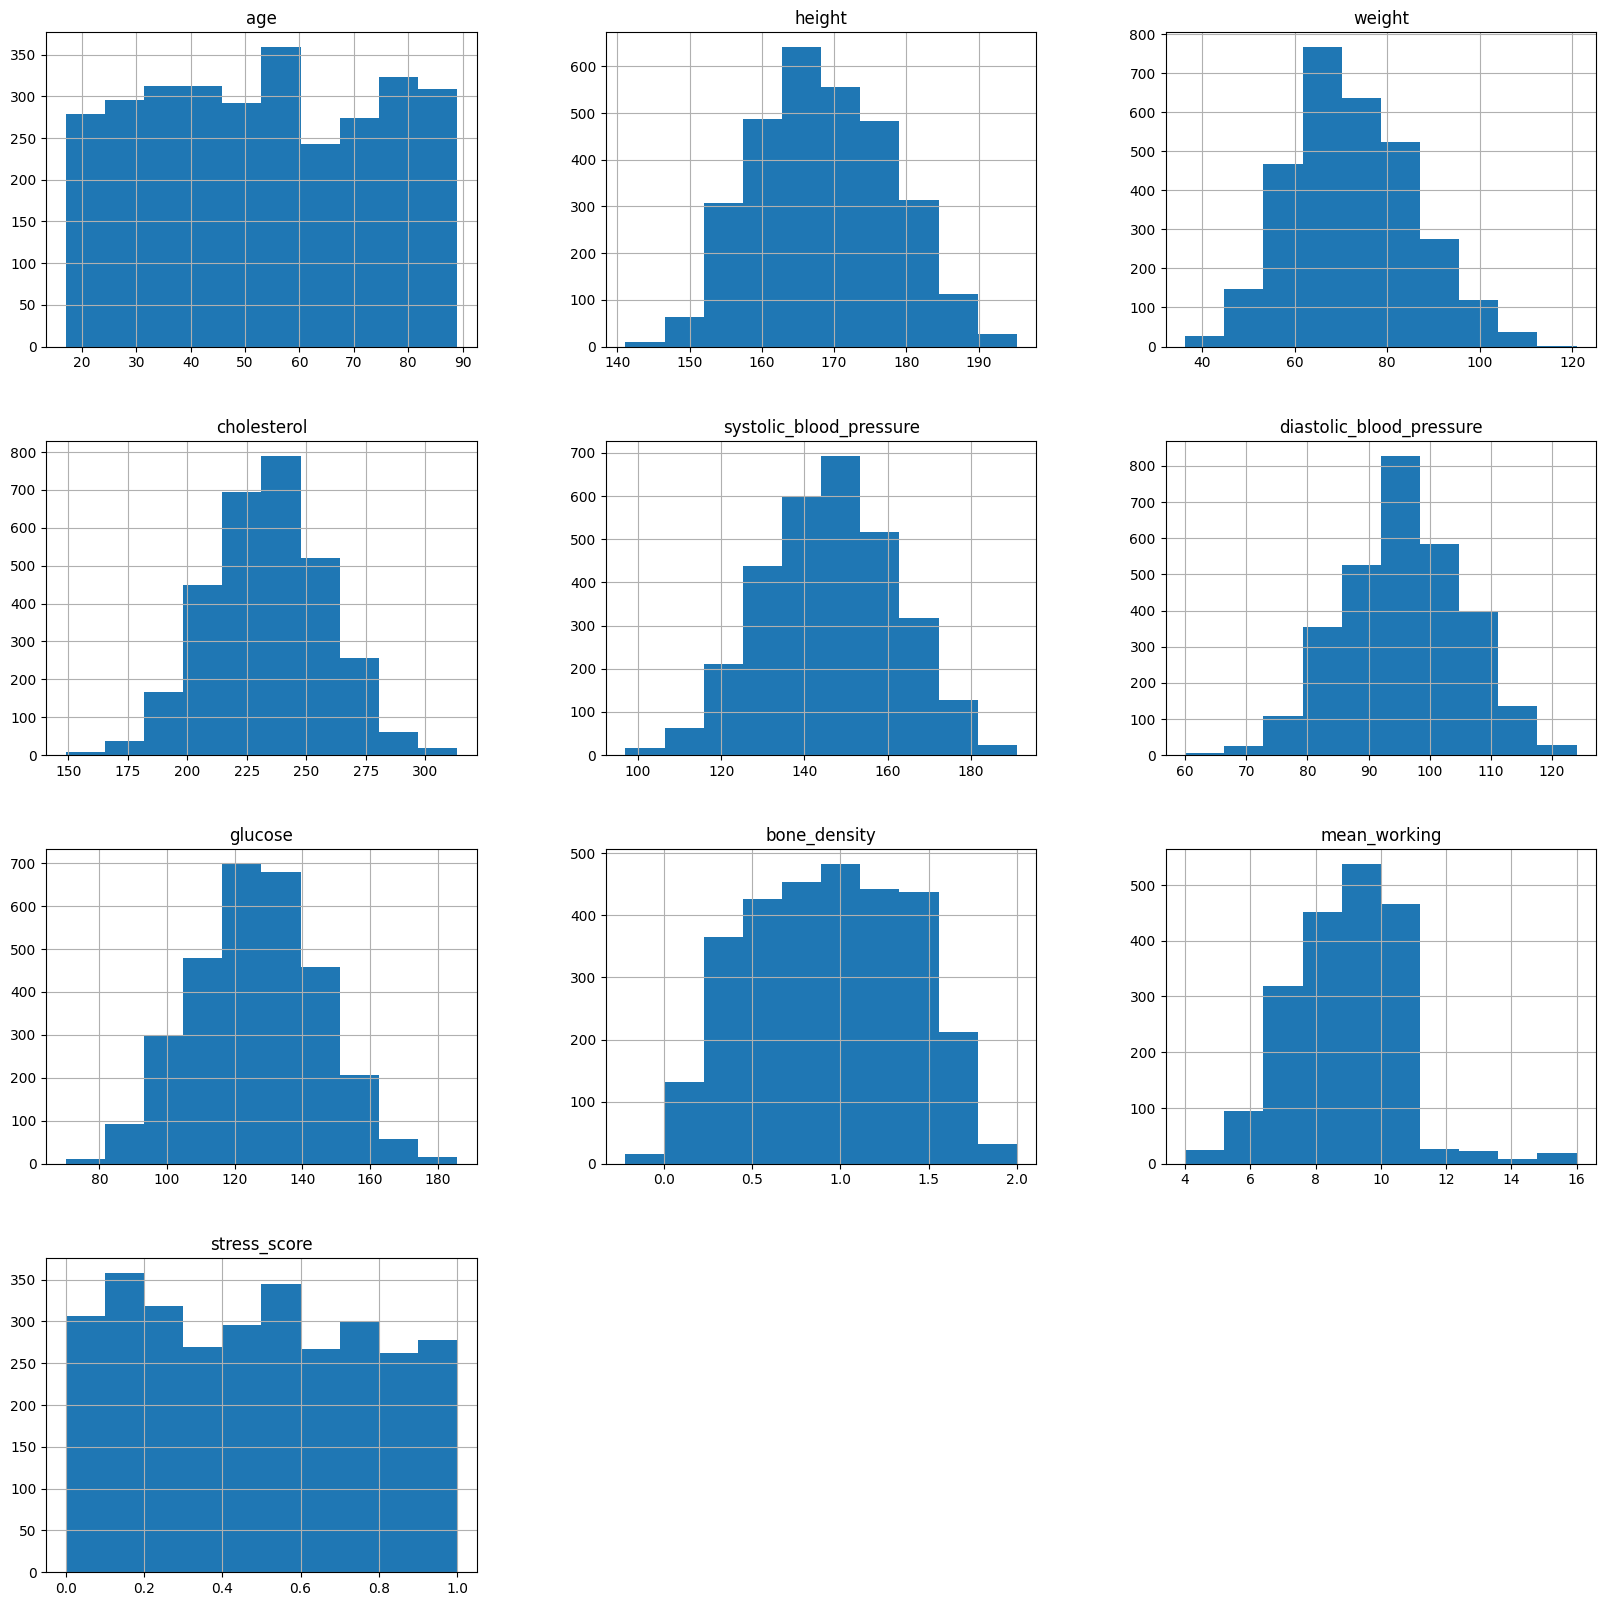

In [ ]:
train.hist(figsize = (20,20))
plt.show()

In [ ]:
train.head()

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,NaN,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,NaN,diabetes,normal,graduate degree,NaN,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,NaN,NaN,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,NaN,oversleeping,graduate degree,NaN,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,NaN,0.36


In [ ]:
import seaborn as sns

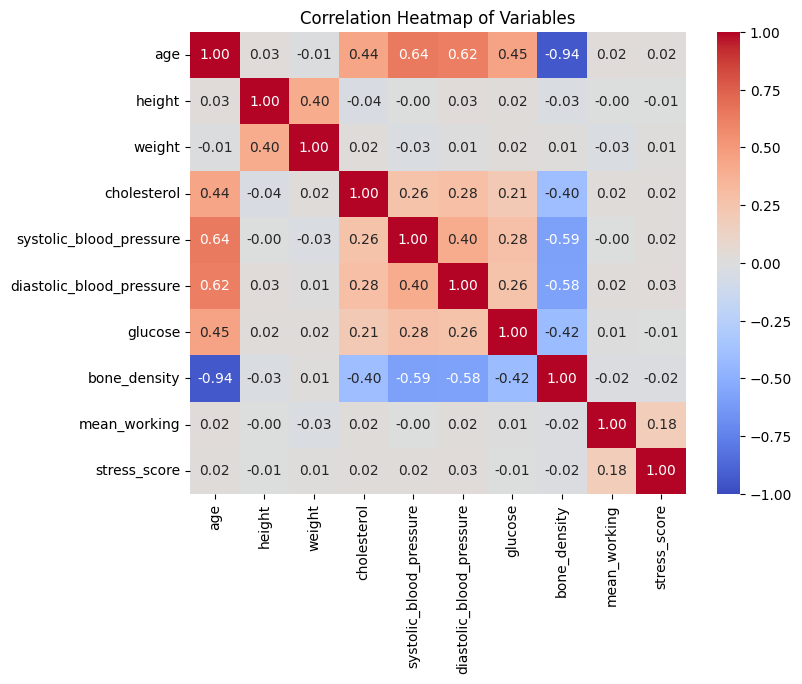

In [ ]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Variables')
plt.show()

In [ ]:
# 1. 범주형(문자열) 컬럼들만 골라서 'cat_cols'라는 이름의 리스트로 만듭니다.
cat_cols = train.select_dtypes(include=['object']).columns

# 2. 이제 정의된 'cat_cols'를 사용하여 각 컬럼의 고유값 개수를 확인합니다.
for col in cat_cols:
    print(f"{col}: {train[col].nunique()} categories")

ID: 3000 categories
gender: 2 categories
activity: 3 categories
smoke_status: 3 categories
medical_history: 3 categories
family_medical_history: 3 categories
sleep_pattern: 3 categories
edu_level: 3 categories


In [ ]:
missing_columns_train = train.columns[train.isnull().sum() > 0]
missing_columns_train

Index(['medical_history', 'family_medical_history', 'edu_level',
       'mean_working'],
      dtype='object')

In [ ]:
train[missing_columns_train].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   medical_history         1711 non-null   object 
 1   family_medical_history  1514 non-null   object 
 2   edu_level               2393 non-null   object 
 3   mean_working            1968 non-null   float64
dtypes: float64(1), object(3)
memory usage: 93.9+ KB


In [ ]:
categorical_na_cols = []
numerical_na_cols = []

# 결측값이 있는 각 칼럼에 대해 데이터 타입 확인
for col in missing_columns_train:
    # 해당 칼럼이 범주형(object 또는 category)인지 확인
    if col in train.select_dtypes(include=['object', 'category']).columns:
        categorical_na_cols.append(col)
    # 해당 칼럼이 수치형(int 또는 float)인지 확인
    elif col in train.select_dtypes(include=['int', 'float']).columns:
        numerical_na_cols.append(col)

print("결측값이 있는 범주형 변수:", categorical_na_cols)
print("결측값이 있는 수치형 변수:", numerical_na_cols)

결측값이 있는 범주형 변수: ['medical_history', 'family_medical_history', 'edu_level']
결측값이 있는 수치형 변수: ['mean_working']


In [ ]:
test = pd.read_csv('/content/drive/MyDrive/스트레스 테스트 9차/test.csv')

In [ ]:
# 범주형 변수의 결측값을 최빈값으로 대체
for col in categorical_na_cols:
    # 학습 데이터에서 최빈값 계산
    most_frequent = train[col].mode()[0]

    # 학습 데이터와 테스트 데이터 모두 해당 칼럼의 최빈값으로 대체
    train[col] = train[col].fillna(most_frequent)
    test[col] = test[col].fillna(most_frequent)

In [ ]:
# mean_working에 대해 중앙값 대체
median_value = train['mean_working'].median()

train['mean_working'] = train['mean_working'].fillna(median_value)
test['mean_working'] = test['mean_working'].fillna(median_value)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# 1. 원-핫 인코더 생성 (범주형 컬럼 리스트 지정)
cat_cols = ['gender', 'activity', 'smoke_status', 'medical_history',
            'family_medical_history', 'sleep_pattern', 'edu_level']

# handle_unknown='ignore': 테스트에 새로운 범주가 나와도 에러 없이 0으로 처리
# sparse_output=False: 결과를 즉시 배열로 반환 (Pandas 결합 용이)
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. Train 데이터로 기준 학습 및 변환
train_cat = oh_encoder.fit_transform(train[cat_cols])
train_cat_df = pd.DataFrame(train_cat, columns=oh_encoder.get_feature_names_out(cat_cols))

# 3. Test 데이터는 'transform'만 수행 (학습 시 기준 그대로 적용)
test_cat = oh_encoder.transform(test[cat_cols])
test_cat_df = pd.DataFrame(test_cat, columns=oh_encoder.get_feature_names_out(cat_cols))

# 4. 기존 수치형 컬럼과 합치기 (ID, target 제외)
train_final = pd.concat([train.drop(columns=cat_cols), train_cat_df], axis=1)
test_final = pd.concat([test.drop(columns=cat_cols), test_cat_df], axis=1)

train_reset = train.drop(columns=cat_cols).reset_index(drop=True)
test_reset = test.drop(columns=cat_cols).reset_index(drop=True)

# 5. 최종 결합
train_final = pd.concat([train_reset, train_cat_df], axis=1)
test_final = pd.concat([test_reset, test_cat_df], axis=1)

# 확인용: 여전히 object 타입이 있는지 체크
print(train_final.select_dtypes(include=['object']).columns)

Index(['ID'], dtype='object')


In [ ]:
display(train.head())
display(test.head())

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,9.0,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,high blood pressure,diabetes,normal,graduate degree,9.0,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,high blood pressure,diabetes,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,diabetes,oversleeping,graduate degree,9.0,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,9.0,0.36


,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working
0,TEST_0000,F,72,161.95,77.66,312.36,137,112,131.16,0.51,moderate,current-smoker,high blood pressure,heart disease,oversleeping,graduate degree,9.0
1,TEST_0001,F,84,152.35,58.70,269.54,162,95,129.36,0.51,intense,current-smoker,high blood pressure,diabetes,normal,graduate degree,9.0
2,TEST_0002,F,45,164.09,76.71,209.08,146,91,169.21,1.13,light,ex-smoker,diabetes,heart disease,sleep difficulty,bachelors degree,6.0
3,TEST_0003,M,58,165.06,76.34,246.52,146,98,133.78,0.52,light,current-smoker,heart disease,heart disease,sleep difficulty,high school diploma,10.0
4,TEST_0004,F,35,158.17,65.60,181.24,142,80,73.93,1.42,moderate,ex-smoker,diabetes,heart disease,oversleeping,high school diploma,7.0


In [ ]:
import numpy as np

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
!pip install catboost optuna shap -q

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
X_train = train_final.drop(['ID', 'stress_score'], axis=1)
y_train = train_final['stress_score']

In [ ]:
from xgboost import XGBRegressor

In [ ]:
import optuna

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
# [필독] 사전 준비: train_final, test_final, y_train 변수가 정의되어 있어야 합니다.
# 1. 데이터 최종 정제 (문자열 제거 및 타겟 변수 분리)
# 학습 데이터에서 숫자형만 남기고, 혹시 포함되었을 ID나 타겟 컬럼을 확실히 제거합니다.
X_train_final = train_final.select_dtypes(exclude=['object']).drop(columns=['stress_score'], errors='ignore')
X_test_final = test_final.select_dtypes(exclude=['object']).drop(columns=['stress_score'], errors='ignore')

In [ ]:
# 2. 개별 모델 최적화 함수 정의 (Optuna)
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'tree_method': 'hist'
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train_final, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -score.mean()

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMRegressor(**params)
    score = cross_val_score(model, X_train_final, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -score.mean()

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'random_state': 42,
        'verbose': 0
    }
    model = CatBoostRegressor(**params)
    score = cross_val_score(model, X_train_final, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -score.mean()

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20)
print(f"XGB Best MAE: {study_xgb.best_value:.4f}")

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=20)
print(f"LGBM Best MAE: {study_lgbm.best_value:.4f}")

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=20)
print(f"CatBoost Best MAE: {study_cat.best_value:.4f}")

[I 2026-03-16 03:44:15,809] A new study created in memory with name: no-name-f249f792-93b5-493f-ae66-df03b978c97a
[I 2026-03-16 03:44:21,234] Trial 0 finished with value: 0.2171687356599793 and parameters: {'n_estimators': 1361, 'max_depth': 3, 'learning_rate': 0.06358863178617748, 'subsample': 0.9803912896362698, 'colsample_bytree': 0.617495703104366}. Best is trial 0 with value: 0.2171687356599793.
[I 2026-03-16 03:44:36,843] Trial 1 finished with value: 0.1952158285876612 and parameters: {'n_estimators': 1389, 'max_depth': 7, 'learning_rate': 0.010551397995834672, 'subsample': 0.65463841473063, 'colsample_bytree': 0.9666805411593921}. Best is trial 1 with value: 0.1952158285876612.
[I 2026-03-16 03:44:42,433] Trial 2 finished with value: 0.19326844969549525 and parameters: {'n_estimators': 1045, 'max_depth': 5, 'learning_rate': 0.06097551454173723, 'subsample': 0.7853304911942083, 'colsample_bytree': 0.7457520171931741}. Best is trial 2 with value: 0.19326844969549525.
[I 2026-03-16

XGB Best MAE: 0.1839


[I 2026-03-16 03:47:50,984] Trial 0 finished with value: 0.20528035023571412 and parameters: {'n_estimators': 1051, 'max_depth': 7, 'learning_rate': 0.028418409512313968, 'num_leaves': 85}. Best is trial 0 with value: 0.20528035023571412.
[I 2026-03-16 03:47:54,363] Trial 1 finished with value: 0.19184287818444568 and parameters: {'n_estimators': 640, 'max_depth': 10, 'learning_rate': 0.09971549346490709, 'num_leaves': 32}. Best is trial 1 with value: 0.19184287818444568.
[I 2026-03-16 03:47:57,424] Trial 2 finished with value: 0.18994154540431532 and parameters: {'n_estimators': 1092, 'max_depth': 9, 'learning_rate': 0.09701792151929108, 'num_leaves': 93}. Best is trial 2 with value: 0.18994154540431532.
[I 2026-03-16 03:48:00,422] Trial 3 finished with value: 0.192222907876591 and parameters: {'n_estimators': 1352, 'max_depth': 7, 'learning_rate': 0.09136877216958103, 'num_leaves': 47}. Best is trial 2 with value: 0.18994154540431532.
[I 2026-03-16 03:48:04,467] Trial 4 finished with

LGBM Best MAE: 0.1848


[I 2026-03-16 03:49:30,570] Trial 0 finished with value: 0.19792927252354217 and parameters: {'iterations': 528, 'depth': 8, 'learning_rate': 0.06734303905382631}. Best is trial 0 with value: 0.19792927252354217.
[I 2026-03-16 03:50:59,709] Trial 1 finished with value: 0.19252716247687682 and parameters: {'iterations': 1476, 'depth': 9, 'learning_rate': 0.02337312824067583}. Best is trial 1 with value: 0.19252716247687682.
[I 2026-03-16 03:51:39,756] Trial 2 finished with value: 0.19914138345681412 and parameters: {'iterations': 770, 'depth': 8, 'learning_rate': 0.04577446474146991}. Best is trial 1 with value: 0.19252716247687682.
[I 2026-03-16 03:51:43,349] Trial 3 finished with value: 0.2270595589521589 and parameters: {'iterations': 792, 'depth': 4, 'learning_rate': 0.044772479977555436}. Best is trial 1 with value: 0.19252716247687682.
[I 2026-03-16 03:53:09,994] Trial 4 finished with value: 0.20885822614038443 and parameters: {'iterations': 778, 'depth': 10, 'learning_rate': 0.01

CatBoost Best MAE: 0.1795


In [ ]:
# 1. 개별 모델 학습 (이미 학습된 모델이 있다면 생략 가능)
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1).fit(X_train, y_train)
xgb_model = XGBRegressor(**study_xgb.best_params).fit(X_train, y_train)
lgbm_model = LGBMRegressor(**study_lgbm.best_params).fit(X_train, y_train)
cat_model = CatBoostRegressor(**study_cat.best_params, verbose=0).fit(X_train, y_train)

# 2. 각 모델의 예측값 생성
rf_pred = rf_model.predict(X_train_final)
xgb_pred = xgb_model.predict(X_train_final)
lgbm_pred = lgbm_model.predict(X_train_final)
cat_pred = cat_model.predict(X_train_final)

# 3. 가중치 설정 (성능 순위: Cat > XGB > LGBM > RF 가정)
# MAE가 낮을수록 성능이 좋으므로 CatBoost에 가장 높은 비중을 둡니다.
weights = {
    'rf': 0.05,
    'xgb': 0.25,
    'lgbm': 0.20,
    'cat': 0.50
}

# 4. 가중 평균 예측
final_pred = (
    rf_pred * weights['rf'] +
    xgb_pred * weights['xgb'] +
    lgbm_pred * weights['lgbm'] +
    cat_pred * weights['cat']
)

from sklearn.metrics import mean_absolute_error
print(f"Blending MAE: {mean_absolute_error(y_train, final_pred):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1474
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 29
[LightGBM] [Info] Start training from score 0.482130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# 1. 데이터 분리 (Hold-out Validation)
# 전체 학습 데이터(X_train, y_train) 중 20%를 검증용(val)으로 떼어둡니다.
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 2. 개별 모델 학습 (X_train_sub 사용)
# (best_params는 기존에 튜닝하신 정보를 그대로 사용한다고 가정합니다)
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1).fit(X_train_sub, y_train_sub)
xgb_model = XGBRegressor(**study_xgb.best_params).fit(X_train_sub, y_train_sub)
lgbm_model = LGBMRegressor(**study_lgbm.best_params).fit(X_train_sub, y_train_sub)
cat_model = CatBoostRegressor(**study_cat.best_params, verbose=0).fit(X_train_sub, y_train_sub)

# 3. 검증 데이터(X_val)에 대한 예측값 생성
rf_val_pred = rf_model.predict(X_val)
xgb_val_pred = xgb_model.predict(X_val)
lgbm_val_pred = lgbm_model.predict(X_val)
cat_val_pred = cat_model.predict(X_val)

# 4. 가중치 설정 (합이 1.0이 되도록 설정)
weights = {
    'rf': 0.05,
    'xgb': 0.25,
    'lgbm': 0.20,
    'cat': 0.50
}

# 5. 가중 평균(Blending) 예측
final_val_pred = (
    rf_val_pred * weights['rf'] +
    xgb_val_pred * weights['xgb'] +
    lgbm_val_pred * weights['lgbm'] +
    cat_val_pred * weights['cat']
)

# 6. 최종 검증 성능 출력
print(f"Random Forest MAE: {mean_absolute_error(y_val, rf_val_pred):.4f}")
print(f"XGBoost MAE: {mean_absolute_error(y_val, xgb_val_pred):.4f}")
print(f"LGBM MAE: {mean_absolute_error(y_val, lgbm_val_pred):.4f}")
print(f"CatBoost MAE: {mean_absolute_error(y_val, cat_val_pred):.4f}")
print("-" * 30)
print(f"Blending (Final) MAE: {mean_absolute_error(y_val, final_val_pred):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1466
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 29
[LightGBM] [Info] Start training from score 0.481912
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [ ]:
# 1. 범주형 컬럼 리스트 정의 (오류 메시지에 나타난 컬럼들)
cat_cols = [
    'activity', 'edu_level', 'family_medical_history', 'gender',
    'medical_history', 'smoke_status', 'sleep_pattern'  # 이 부분을 추가했습니다
]


# 2. 인코더 생성 및 학습 (전체 데이터 기반으로 범주 누락 방지)
# handle_unknown='ignore'는 테스트 세트에 처음 보는 값이 나와도 에러를 내지 않고 0으로 채웁니다.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(train[cat_cols]) # 원래 학습 데이터의 범주형 컬럼으로 피팅

# 3. 테스트 데이터 변환
test_encoded = ohe.transform(test[cat_cols])
test_encoded_df = pd.DataFrame(test_encoded, columns=ohe.get_feature_names_out(cat_cols))

# 4. 기존 수치형 컬럼과 결합
test_numeric = test.drop(columns=cat_cols)
X_test_final = pd.concat([test_numeric, test_encoded_df], axis=1)

# 5. 모델 학습 시 사용한 컬럼 순서와 정확히 일치시키기 (매우 중요)
X_test_final = X_test_final[X_train.columns]

# 6. 예측 재실행
rf_test_pred = rf_model.predict(X_test_final)
xgb_test_pred = xgb_model.predict(X_test_final)
lgbm_test_pred = lgbm_model.predict(X_test_final)
cat_test_pred = cat_model.predict(X_test_final)

# 7. 블렌딩 및 저장
final_test_pred = (
    rf_test_pred * weights['rf'] +
    xgb_test_pred * weights['xgb'] +
    lgbm_test_pred * weights['lgbm'] +
    cat_test_pred * weights['cat']
).round(2)


In [ ]:
submission = pd.read_csv('/content/drive/MyDrive/스트레스 테스트 9차/sample_submission.csv')

In [ ]:
submission['stress_score'] = final_pred
submission.head()

,ID,stress_score
0,TEST_0000,0.629459
1,TEST_0001,0.826913
2,TEST_0002,0.690555
3,TEST_0003,0.174026
4,TEST_0004,0.359065


In [ ]:
submission.to_csv('/content/drive/MyDrive/스트레스 테스트 9차/sample_submission.csv', index=False, float_format='%.2f')